<a href="https://colab.research.google.com/github/Fchoupani/AD-project-/blob/main/Deep_Learning_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Torch** (pytorch is alread installed in colab)

In [1]:
import torch

**Creating Tensors**

In [2]:
tensor0d = torch.tensor(4)
tensor1d = torch.tensor([1,2,3])
tensor2d = torch.tensor([[1,2,3],[4,5,6]])

In [3]:
tensor3d = torch.randn(3,4,5)

In [4]:
tensor3d

tensor([[[ 1.1037,  1.7882, -1.8129,  1.9121,  1.0157],
         [-0.7708, -0.2171,  0.2978, -0.1279,  0.9183],
         [ 1.8510,  0.1740,  0.5747,  1.0578, -0.1713],
         [ 0.4430, -0.0710,  1.3794,  0.0347, -1.1417]],

        [[ 0.4431, -0.4559, -0.1780, -0.5624,  2.1802],
         [-0.8898, -0.7970,  0.1707,  0.7678, -1.9989],
         [ 1.7464, -0.1223, -0.3341,  1.3598,  2.5864],
         [ 0.1352, -0.4403, -0.4749,  0.0168, -0.9677]],

        [[-0.4874,  1.0886,  0.4314, -0.6613,  0.4194],
         [-0.9725, -0.6299, -1.9269,  0.7250, -0.1261],
         [ 1.0809, -1.6258,  0.7877, -0.5709, -0.6441],
         [ 0.2432,  0.2906,  1.3628, -1.6445,  1.9035]]])

**Mathematics with Tensors**

In [ ]:
# Create a tensor of values and add a number to it
tensor = torch.tensor([1, 2, 3])
tensor + 10

tensor([11, 12, 13])

In [ ]:
# Multiply it by 10
tensor * 10

tensor([10, 20, 30])

In [ ]:
# Can also use torch functions
torch.multiply(tensor, 10)

tensor([10, 20, 30])

In [ ]:
# Subtract and reassign
tensor = tensor - 10
tensor

tensor([-9, -8, -7])

In [ ]:
#Elementwise Multiplication
tensor*tensor

tensor([81, 64, 49])

In [5]:
tensor1 = torch.tensor([1,2,3,5])


In [14]:
tensor = torch.tensor([-9, -8, -7], dtype=torch.float32) # Re-defining tensor as float32
tensor1 = torch.tensor([1, 2, 3], dtype=torch.float32) # Redefine tensor1 as float32 to match tensor's data type
tensor*tensor1

tensor([ -9., -16., -21.])

In [16]:
tensor = torch.tensor([-9, -8, -7], dtype=torch.float32)
tensor1 = torch.tensor([1, 2, 3], dtype=torch.float32)
tensor.shape, tensor1.shape

(torch.Size([3]), torch.Size([3]))

In [13]:
print(torch.sin(tensor)) #useful operations
print(torch.log(tensor))
print(torch.mean(tensor))
print(torch.max(tensor))
print(torch.min(tensor))
print(torch.sum(tensor))

tensor([-0.4121, -0.9894, -0.6570])
tensor([nan, nan, nan])


RuntimeError: mean(): could not infer output dtype. Input dtype must be either a floating point or complex dtype. Got: Long

In [17]:
tensor = tensor.to(torch.float32) #torch values can have certain Dataypes float, long, double, etc.,

**Matrix Multiplications**

In [18]:
tensor = torch.tensor([1,2,3])

In [19]:
tensor@tensor

tensor(14)

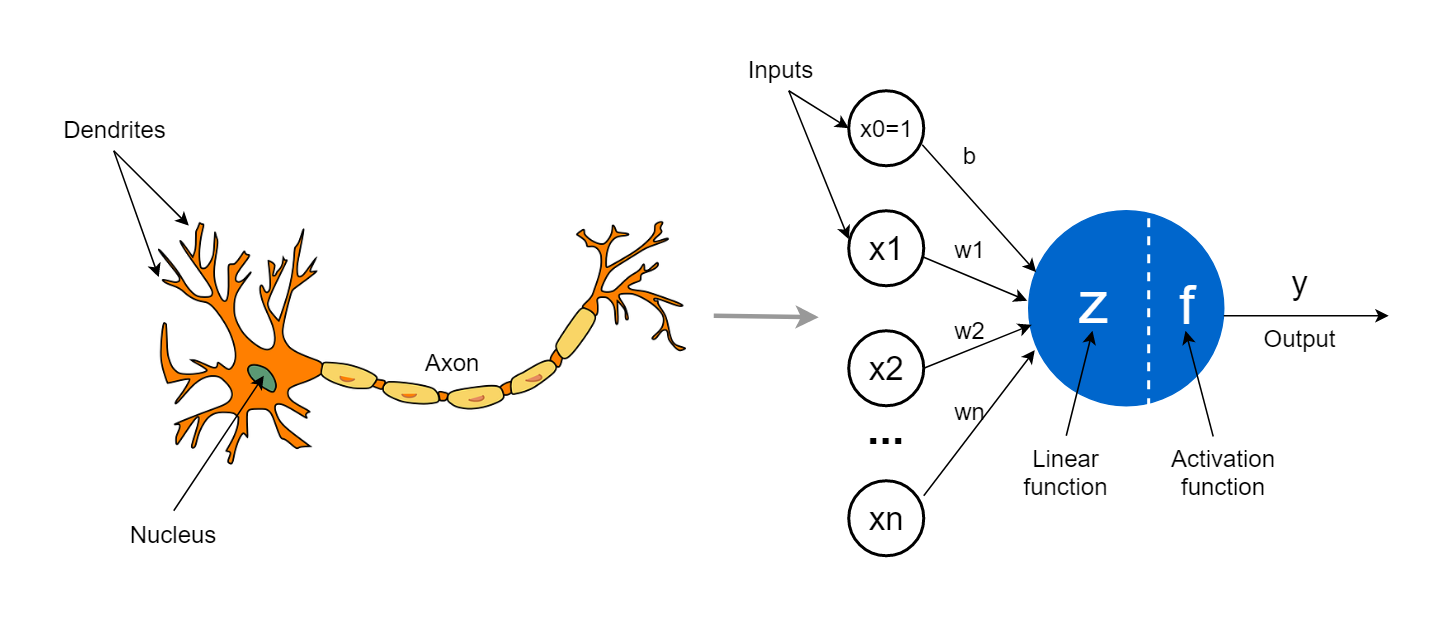

In [ ]:
torch.matmul(tensor,tensor)

tensor(14)

In [21]:
# Shapes need to be in the right way
tensor_A = torch.tensor([[1, 2],
                         [3, 4],
                         [5, 6]], dtype=torch.float32)

tensor_B = torch.tensor([[7, 10],
                         [8, 11],
                         [9, 12]], dtype=torch.float32)



In [23]:
torch.matmul(tensor_A, tensor_B.T) # Fix: Transpose tensor_B to allow matrix multiplication

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])

In [25]:
tensor_A, tensor_A.T

(tensor([[1., 2.],
         [3., 4.],
         [5., 6.]]),
 tensor([[1., 3., 5.],
         [2., 4., 6.]]))

In [ ]:
tensor_B, tensor_B.T

(tensor([[ 7., 10.],
         [ 8., 11.],
         [ 9., 12.]]),
 tensor([[ 7.,  8.,  9.],
         [10., 11., 12.]]))

In [ ]:
tensor_A@tensor_B.T

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])

**Creating your First Layer of Artificial Neurons**

In [26]:
torch.manual_seed(42)

In [28]:
weights = torch.randn(2,6)
Layer1 = torch.nn.Parameter(weights)

In [30]:
input = torch.randn(3, 2) # Define input as a tensor, for example, a random tensor
output = torch.matmul(input, Layer1)

In [31]:
print(input.shape, output.shape)

torch.Size([3, 2]) torch.Size([3, 6])


**Alternate way to create a Neural Layer**



In [32]:

linear = torch.nn.Linear(in_features=2, # in_features = matches inner dimension of input
                         out_features=6)



In [33]:
input = tensor_A
output = linear(input)

In [ ]:
print(input.shape, output.shape)

torch.Size([3, 2]) torch.Size([3, 6])


**Creating A complete Layer**



In [34]:
#same initialization as before
weights = torch.randn(2,6)
Layer1 = torch.nn.Parameter(weights)

Adding a bias and activation



In [35]:
bias = torch.randn(6)
Layer1_bias = torch.nn.Parameter(bias) #creating a bias
activation = torch.nn.ReLU() #creating an activation layer

![Spiking animation](https://picower.mit.edu/sites/default/files/2019-07/Mouse%20visual%20cortex_mpeg4.gif)

In [36]:
output1 = torch.matmul(input, Layer1)
output2 = output1 + Layer1_bias
output_final = activation(output2) #alternatively output_final = torch.relu(output2)

In [38]:
#you can also simply write in one line
output_final = torch.relu(torch.matmul(input, Layer1) + Layer1_bias)

**Visualization of Computation Graphs and Backpropagation**



In [39]:
!pip install torchviz

In [40]:
from torchviz import make_dot


In [41]:
# --------------------- 1. CREATE A COMPLETE LAYER ---------------------

# Input: batch of 4 samples, 2 features each
input = torch.randn(3, 2)

# Initialize weights and bias as learnable Parameters
weights = torch.randn(2, 6)
Layer1 = torch.nn.Parameter(weights)

bias = torch.randn(6)
Layer1_bias = torch.nn.Parameter(bias)

# Build the layer step by step (exactly as you wrote)
output1 = torch.matmul(input, Layer1)
output2 = output1 + Layer1_bias
activation = torch.nn.ReLU()
output_final = activation(output2)

# Or in one line:
# output_final = torch.relu(torch.matmul(input, Layer1) + Layer1_bias)

# --------------------- 2. TORCHVIZ COMPUTATION GRAPH ---------------------

# Create the graph from the final tensor
# The params dict tells torchviz which nodes to highlight as "inputs"
dot = make_dot(output_final, params={
    'input': input,
    'Layer1': Layer1,
    'Layer1_bias': Layer1_bias,
    'output_final': output_final
})

# Save to PNG (opens in any image viewer)
dot.render("complete_layer_graph", format="png", cleanup=True)

'complete_layer_graph.png'

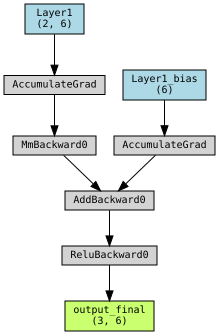

In [42]:
dot

**Understanding BackPropagation**



In [43]:
import numpy as np

# ==================== 1. FORWARD PASS (tiny, traceable numbers) ====================
X  = torch.tensor([[1.0, 2.0]])          # (1, 2)  one sample, two features
y  = torch.tensor([[1.0]])               # (1, 1)  target

W1 = torch.tensor([[0.1, 0.2],
                   [0.3, 0.4]], requires_grad=True)   # (2, 2)
b1 = torch.tensor([0.1, 0.2], requires_grad=True)      # (2,)

W2 = torch.tensor([[0.5],
                   [0.6]], requires_grad=True)       # (2, 1)
b2 = torch.tensor([0.1], requires_grad=True)          # (1,)

# Forward with explicit intermediate names
z  = torch.matmul(X, W1) + b1           # pre-activation layer 1
z2 = torch.relu(z)                      # activation layer 1
z3 = torch.matmul(z2, W2) + b2           # output layer
loss = torch.mean((y - z3) ** 2)          # MSE

print("Forward values:")
print(f"  z  (pre-ReLU)  = {z.detach().numpy()}")
print(f"  z2 (post-ReLU) = {z2.detach().numpy()}")
print(f"  z3 (output)    = {z3.detach().numpy()}")
print(f"  loss           = {loss.item():.6f}")

# ==================== 2. TORCHVIZ GRAPH (3 lines) ====================
# Install first:  pip install torchviz graphviz
from torchviz import make_dot
dot = make_dot(loss, params={'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2})
dot.render("backprop_graph", format="png")   # saves backprop_graph.png
# dot                                        # use this in Jupyter to show inline



Forward values:
  z  (pre-ReLU)  = [[0.8000001 1.2      ]]
  z2 (post-ReLU) = [[0.8000001 1.2      ]]
  z3 (output)    = [[1.2200001]]
  loss           = 0.048400


'backprop_graph.png'

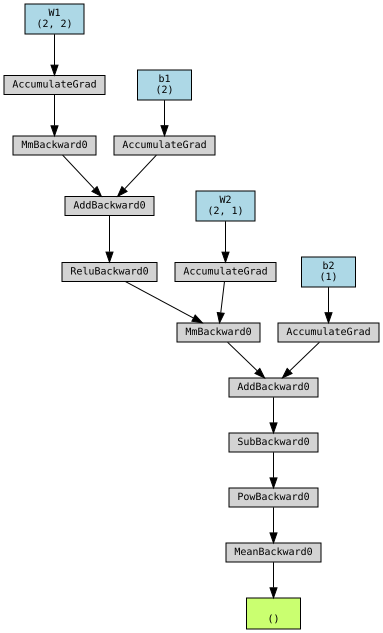

In [ ]:
dot

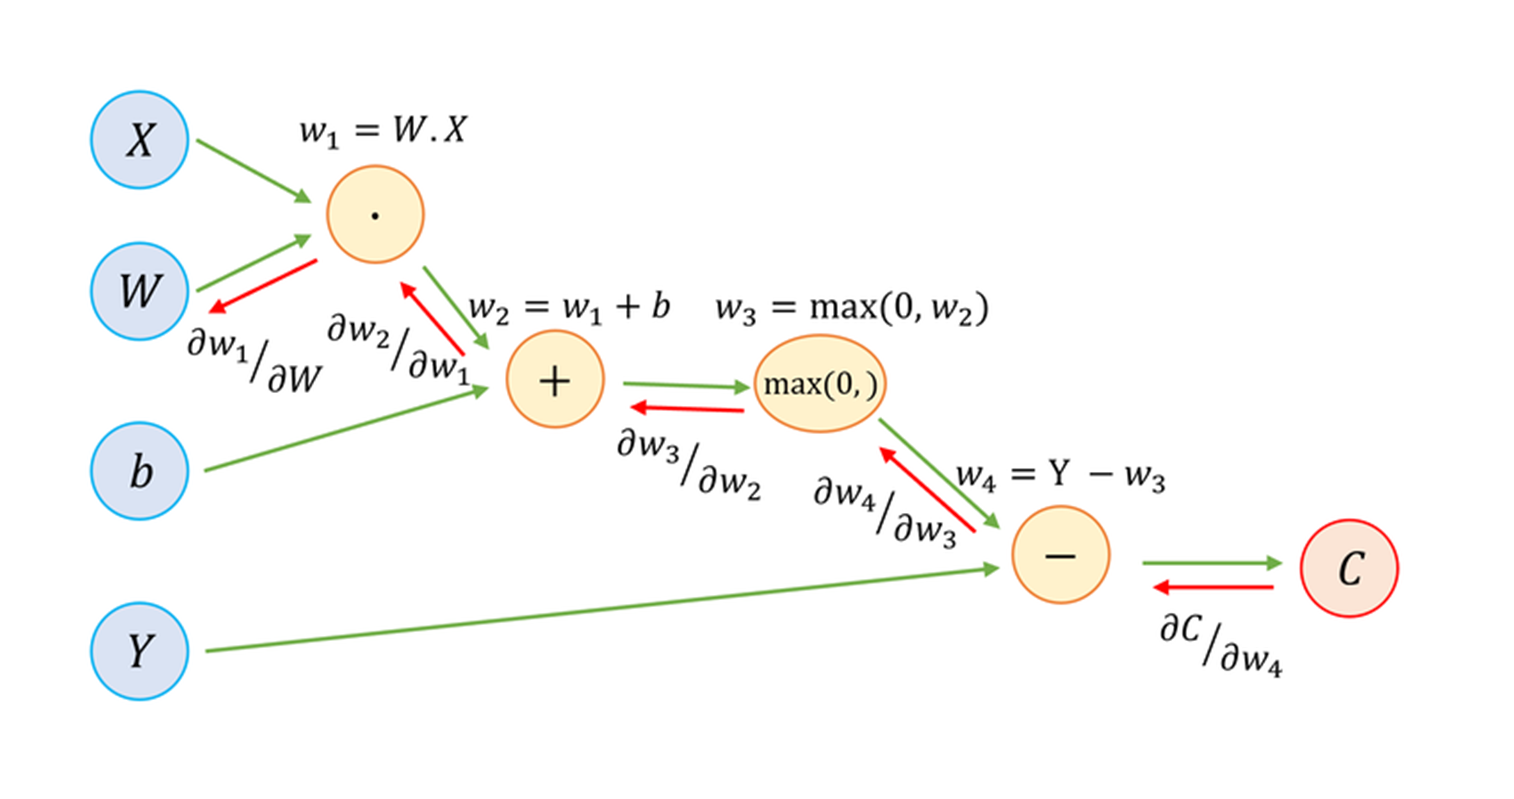

**Manually Calculating Gradient**

In [45]:
# ==================== 3. MANUAL BACKPROP (no torch autograd) ====================
# Pull values into numpy so we only use +, *, and matrix rules
X_np  = X.numpy();  y_np = y.numpy()
W1_np = W1.detach().numpy();  b1_np = b1.detach().numpy()
z_np  = z.detach().numpy();   z2_np = z2.detach().numpy()
W2_np = W2.detach().numpy();  b2_np = b2.detach().numpy()
z3_np = z3.detach().numpy()

N = X_np.shape[0]   # batch size = 1

# STEP 1 — loss → z3
# L = (1/N) * Σ(y - z3)^2   →   dL/dz3 = (2/N)*(z3 - y)
dL_dz3 = (2.0 / N) * (z3_np - y_np)

# STEP 2 — z3 → W2, b2
# z3 = z2 @ W2 + b2
dL_dW2 = z2_np.T @ dL_dz3          # (2,1) = (2,1)·(1,1)
dL_db2 = np.sum(dL_dz3, axis=0)    # sum over batch

# STEP 3 — z3 → z2 (backprop through linear layer 2)
# dL/dz2 = dL/dz3 @ W2^T
dL_dz2 = dL_dz3 @ W2_np.T          # (1,2) = (1,1)·(1,2)

# STEP 4 — z2 → z (backprop through ReLU)
# ReLU'(z) = 1 if z>0 else 0
mask = (z_np > 0).astype(float)
dL_dz = dL_dz2 * mask              # element-wise

# STEP 5 — z → W1, b1
# z = X @ W1 + b1
dL_dW1 = X_np.T @ dL_dz            # (2,2) = (2,1)·(1,2)
dL_db1 = np.sum(dL_dz, axis=0)

**Using Pytorch to Compute Backward Graph and Gradient**

In [46]:
loss.backward()   # let PyTorch do its thing

In [48]:


print("\nManual vs. Torch autograd:")
print(f"dW2 : manual {dL_dW2.flatten()}  |  torch {W2.grad.numpy().flatten()}")
print(f"db2 : manual {dL_db2.flatten()}  |  torch {b2.grad.numpy().flatten()}")
print(f"dW1 : manual\n{dL_dW1}\n      torch\n{W1.grad.numpy()}")
print(f"db1 : manual {dL_db1}  |  torch {b1.grad.numpy()}")


Manual vs. Torch autograd:
dW2 : manual [0.35200027 0.52800035]  |  torch [0.35200027 0.52800035]
db2 : manual [0.4400003]  |  torch [0.4400003]
dW1 : manual
[[0.22000015 0.26400018]
 [0.4400003  0.52800035]]
      torch
[[0.22000015 0.26400018]
 [0.4400003  0.52800035]]
db1 : manual [0.22000015 0.26400018]  |  torch [0.22000015 0.26400018]


**DataSets and Training**

In [49]:
from torch.utils.data import TensorDataset, DataLoader, random_split

Creating the Data

In [51]:

torch.manual_seed(42)
np.random.seed(42)

n_samples = 1000

# Real-world farm measurements
water_liters   = np.random.uniform(10, 40, n_samples)   # 10–40 L/day
sunlight_hours = np.random.uniform(4, 10, n_samples)    # 4–10 hrs/day
noise          = np.random.normal(0, 8, n_samples)      # nature's randomness

# Underlying physical law the network will discover
tomato_yield_kg = 2.5 * water_liters + 1.8 * sunlight_hours + noise



*Convert to tensors*

In [52]:

X = torch.tensor(np.column_stack([water_liters, sunlight_hours]), dtype=torch.float32)
y = torch.tensor(tomato_yield_kg, dtype=torch.float32).view(-1, 1)

*Normalize the Datasets*

In [53]:
# Normalize for stable SGD training
X_mean, X_std = X.mean(dim=0), X.std(dim=0)
X = (X - X_mean) / X_std

y_mean, y_std = y.mean(), y.std()
y = (y - y_mean) / y_std

*Split Data into Train and Test*

In [54]:
dataset = TensorDataset(X, y)

train_size = int(0.8 * n_samples)          # 800 samples
val_size   = n_samples - train_size        # 200 samples
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Batch size 32 is a classic teaching default
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# --------------------- 3. NEURAL NETWORK ---------------------
class Neural_Network(nn.Module):
    def __init__(self):
        super(Neural_Network, self).__init__()
        self.inputSize  = 2
        self.outputSize = 1
        self.hiddenSize = 4

        self.W1 = torch.nn.Parameter(torch.randn(self.inputSize, self.hiddenSize))
        self.W2 = torch.nn.Parameter(torch.randn(self.hiddenSize, self.outputSize))

    def forward(self, X):
        self.z  = torch.matmul(X, self.W1)
        self.z2 = torch.relu(self.z)
        self.z3 = torch.matmul(self.z2, self.W2)
        o = self.z3
        return o

    def backward(self, X, y, o, optimizer):
        loss = torch.mean((y - o)**2)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        return loss

    def train(self, train_loader, val_loader=None, epochs=100, learning_rate=0.05):
        """
        Modified from the original to accept DataLoaders.
        Iterates over batches and tracks validation loss on the held-out 20%.
        """
        optimizer = torch.optim.SGD(self.parameters(), lr=learning_rate)
        history = {'train_loss': [], 'val_loss': []}

        for epoch in range(epochs):
            # ---- Training: iterate over mini-batches ----
            epoch_train_loss = 0.0
            for X_batch, y_batch in train_loader:
                o = self.forward(X_batch)
                loss = self.backward(X_batch, y_batch, o, optimizer)
                epoch_train_loss += loss.item()

            avg_train_loss = epoch_train_loss / len(train_loader)
            history['train_loss'].append(avg_train_loss)

            # ---- Validation: no gradients ----
            if val_loader is not None:
                epoch_val_loss = 0.0
                with torch.no_grad():
                    for X_val, y_val in val_loader:
                        o_val = self.forward(X_val)
                        epoch_val_loss += torch.mean((y_val - o_val)**2).item()

                avg_val_loss = epoch_val_loss / len(val_loader)
                history['val_loss'].append(avg_val_loss)

                if (epoch + 1) % 20 == 0:
                    print(f"Epoch {epoch+1:3d}/{epochs} | "
                          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        return history

    def predict(self, X):
        print("Predicted data based on trained weights: ")
        print("Input (scaled): \n" + str(X))
        with torch.no_grad():
            out = self.forward(X)
        print("Output: \n" + str(out))
        return out


In [ ]:
model = Neural_Network()
history = model.train(train_loader, val_loader, epochs=100, learning_rate=0.05)

Epoch  20/100 | Train Loss: 0.2109 | Val Loss: 0.2018
Epoch  40/100 | Train Loss: 0.1168 | Val Loss: 0.1272
Epoch  60/100 | Train Loss: 0.1135 | Val Loss: 0.1132
Epoch  80/100 | Train Loss: 0.1125 | Val Loss: 0.1124
Epoch 100/100 | Train Loss: 0.1125 | Val Loss: 0.1123


In [ ]:
# --------------------- 5. INSPECT VALIDATION RESULTS ---------------------
X_val = X[val_dataset.indices]
y_val = y[val_dataset.indices]

with torch.no_grad():
    preds_norm = model.forward(X_val)

# De-normalize back to real-world kg for interpretability
preds_kg   = preds_norm * y_std + y_mean
actual_kg  = y_val * y_std + y_mean

print("\nSample validation predictions:")
for i in range(5):
    idx = val_dataset.indices[i]
    print(f"Water {water_liters[idx]:.1f}L, Sun {sunlight_hours[idx]:.1f}h  →  "
          f"Actual: {actual_kg[i].item():.1f}kg,  Predicted: {preds_kg[i].item():.1f}kg")


Sample validation predictions:
Water 25.7L, Sun 8.8h  →  Actual: 90.8kg,  Predicted: 80.1kg
Water 15.3L, Sun 6.6h  →  Actual: 49.6kg,  Predicted: 49.3kg
Water 21.5L, Sun 4.1h  →  Actual: 66.4kg,  Predicted: 60.0kg
Water 24.8L, Sun 7.6h  →  Actual: 72.7kg,  Predicted: 75.6kg
Water 39.0L, Sun 8.2h  →  Actual: 111.4kg,  Predicted: 112.1kg


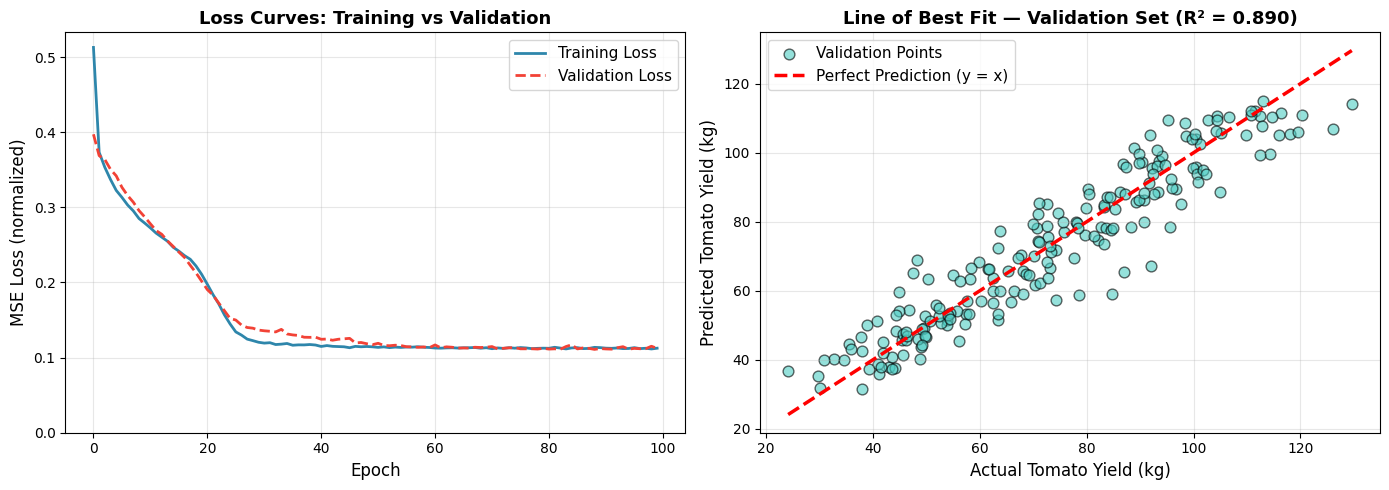


Plots saved! R² score on validation: 0.8899


In [ ]:
import matplotlib.pyplot as plt

# 6. PLOTTING — Loss Curves + Line of Best Fit
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------- Plot 1: Training & Validation Loss ----------
ax1 = axes[0]
ax1.plot(history['train_loss'], label='Training Loss', color='#2E86AB', linewidth=2)
ax1.plot(history['val_loss'], label='Validation Loss', color='#F24236', linewidth=2, linestyle='--')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('MSE Loss (normalized)', fontsize=12)
ax1.set_title('Loss Curves: Training vs Validation', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# ---------- Plot 2: Line of Best Fit (Predicted vs Actual) ----------
ax2 = axes[1]

# Scatter plot: actual vs predicted on validation set
ax2.scatter(actual_kg.numpy(), preds_kg.numpy(),
            alpha=0.6, edgecolors='k', s=60, color='#4ECDC4', label='Validation Points')

# Perfect prediction line (y = x)
min_val = min(actual_kg.min().item(), preds_kg.min().item())
max_val = max(actual_kg.max().item(), preds_kg.max().item())
ax2.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2.5, label='Perfect Prediction (y = x)')

# Compute and display R² score for the validation set
ss_res = torch.sum((actual_kg - preds_kg) ** 2).item()
ss_tot = torch.sum((actual_kg - actual_kg.mean()) ** 2).item()
r2_score = 1 - (ss_res / ss_tot)

ax2.set_xlabel('Actual Tomato Yield (kg)', fontsize=12)
ax2.set_ylabel('Predicted Tomato Yield (kg)', fontsize=12)
ax2.set_title(f'Line of Best Fit — Validation Set (R² = {r2_score:.3f})',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_and_bestfit.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlots saved! R² score on validation: {r2_score:.4f}")

**Model Explainability**

In [ ]:
# For every validation sample...
x_i = X_val[i:i+1].clone().requires_grad_(True)   # tell PyTorch: "I want grad w.r.t. INPUT"
pred_i = model(x_i)                                # forward
pred_i.backward()                                  # backward from PREDICTION to input
importance = x_i.grad.abs()

A cleaner way to do it

In [ ]:
X_val = X[val_dataset.indices]   # (200, 2)

sensitivities = []
for i in range(len(val_dataset)):
    x_i = X_val[i:i+1].clone().requires_grad_(True)
    pred_i = model(x_i)
    pred_i.backward()
    sensitivities.append(x_i.grad.abs().numpy().flatten())

In [ ]:
print(sensitivities)

[array([0.93571913, 0.12178271], dtype=float32), array([0.97182155, 0.15952478], dtype=float32), array([0.97182155, 0.15952478], dtype=float32), array([0.93571913, 0.12178271], dtype=float32), array([0.93571913, 0.12178271], dtype=float32), array([0.93571913, 0.12178271], dtype=float32), array([0.97182155, 0.15952478], dtype=float32), array([0.93571913, 0.12178271], dtype=float32), array([0.93571913, 0.12178271], dtype=float32), array([0.93571913, 0.12178271], dtype=float32), array([0.93571913, 0.12178271], dtype=float32), array([0.93571913, 0.12178271], dtype=float32), array([0.97182155, 0.15952478], dtype=float32), array([0.93571913, 0.12178271], dtype=float32), array([0.97182155, 0.15952478], dtype=float32), array([0.97182155, 0.15952478], dtype=float32), array([0.97182155, 0.15952478], dtype=float32), array([0.97182155, 0.15952478], dtype=float32), array([0.93571913, 0.12178271], dtype=float32), array([0.97182155, 0.15952478], dtype=float32), array([0.97182155, 0.15952478], dtype=f

In [ ]:
sensitivities = np.array(sensitivities)

print(sensitivities.shape)

(200, 2)


In [ ]:
sensitivities = np.array(sensitivities)
water_sens = sensitivities[:, 0].mean()
sun_sens   = sensitivities[:, 1].mean()

# Elegant no-gradient verification
composed = np.abs(model.W1.detach().numpy() * model.W2.detach().numpy().T)
weight_importance = composed.sum(axis=1)

print(f"|∂ŷ/∂water| = {water_sens:.3f}")
print(f"|∂ŷ/∂sun|   = {sun_sens:.3f}")
print(f"Composed weights: {weight_importance}")

|∂ŷ/∂water| = 0.974
|∂ŷ/∂sun|   = 0.146
Composed weights: [3.4877973 0.7434019]


Plotting the important Features

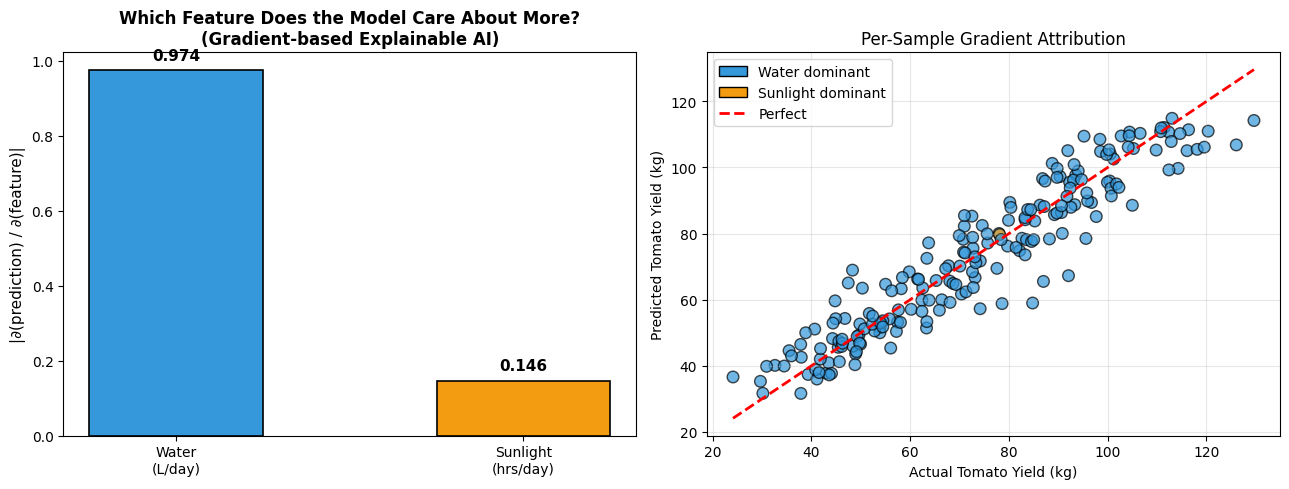

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Bar chart — which feature does the model care about?
ax1 = axes[0]
features = ['Water\n(L/day)', 'Sunlight\n(hrs/day)']
colors = ['#3498db', '#f39c12']
bars = ax1.bar(features, [water_sens, sun_sens], color=colors,
               edgecolor='black', linewidth=1.2, width=0.5)
ax1.set_ylabel('|∂(prediction) / ∂(feature)|', fontsize=11)
ax1.set_title('Which Feature Does the Model Care About More?\n(Gradient-based Explainable AI)',
              fontsize=12, fontweight='bold')
for bar, val in zip(bars, [water_sens, sun_sens]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Per-sample attribution — every dot colored by its dominant driver
ax2 = axes[1]
with torch.no_grad():
    preds_norm = model.forward(X_val)
preds_kg = preds_norm * y_std + y_mean
actual_kg = (y_val * y_std + y_mean).numpy()

dominant = np.argmax(sensitivities, axis=1)  # 0=water, 1=sun
point_colors = np.where(dominant == 0, '#3498db', '#f39c12')

ax2.scatter(actual_kg, preds_kg.numpy(), c=point_colors,
            alpha=0.7, edgecolors='k', s=70)
min_v, max_v = actual_kg.min(), actual_kg.max()
ax2.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', edgecolor='k', label='Water dominant'),
    Patch(facecolor='#f39c12', edgecolor='k', label='Sunlight dominant'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Perfect')
]
ax2.legend(handles=legend_elements, loc='upper left')
ax2.set_xlabel('Actual Tomato Yield (kg)')
ax2.set_ylabel('Predicted Tomato Yield (kg)')
ax2.set_title('Per-Sample Gradient Attribution')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('explainable_ai.png', dpi=150)
plt.show()